# Train a Machine Learning Model
Determine the optimal machine learning algorithm and train it.

In [4]:
%matplotlib inline
import sys
import os
sys.path.append(f"../Al_data")
from glob import glob
from copy import deepcopy
from glob import glob
from matminer.featurizers.function import FunctionFeaturizer
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_validate, cross_val_predict, RepeatedKFold, GridSearchCV
from sklearn.linear_model import BayesianRidge, LinearRegression, Lasso, LassoLars
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import Pipeline
from stopping_power_ml.utils.io import load_qbox_data
import pandas as pd
import numpy as np
import pickle as pkl
import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
import warnings; warnings.simplefilter('ignore')

## Load in the Dataset
This was created by a different notebook

In [8]:
data = pd.read_pickle(os.path.join('data', 'random_data_chrg_1_atoms.pkl.gz'))
print('Data set size:', len(data))

Data set size: 9800


Remove the initial transient

In [9]:
data.query('initial == False', inplace=True)
print('Training set size:', len(data))

Training set size: 9379


Determine which columns are inputs

In [10]:
featurizers = pkl.load(open(os.path.join('data', 'featurizers_chrg_1_atoms.pkl'), 'rb'))

In [11]:
print(type(featurizers))
X_cols = featurizers.feature_labels()

<class 'matminer.featurizers.base.MultipleFeaturizer'>


In [12]:
X_cols.append('timestep')
X_cols

['charge density at offset (0.00, 0.00, 0.00)',
 'distance_to_atom_0',
 'AGNI_x in Al eta=8.00e-01',
 'AGNI_y in Al eta=8.00e-01',
 'AGNI_z in Al eta=8.00e-01',
 'AGNI_x in Al eta=1.23e+00',
 'AGNI_y in Al eta=1.23e+00',
 'AGNI_z in Al eta=1.23e+00',
 'AGNI_x in Al eta=1.88e+00',
 'AGNI_y in Al eta=1.88e+00',
 'AGNI_z in Al eta=1.88e+00',
 'AGNI_x in Al eta=2.89e+00',
 'AGNI_y in Al eta=2.89e+00',
 'AGNI_z in Al eta=2.89e+00',
 'AGNI_x in Al eta=4.43e+00',
 'AGNI_y in Al eta=4.43e+00',
 'AGNI_z in Al eta=4.43e+00',
 'AGNI_x in Al eta=6.80e+00',
 'AGNI_y in Al eta=6.80e+00',
 'AGNI_z in Al eta=6.80e+00',
 'AGNI_x in Al eta=1.04e+01',
 'AGNI_y in Al eta=1.04e+01',
 'AGNI_z in Al eta=1.04e+01',
 'AGNI_x in Al eta=1.60e+01',
 'AGNI_y in Al eta=1.60e+01',
 'AGNI_z in Al eta=1.60e+01',
 'timestep']

In [13]:
y_col = 'force'
data[y_col]

15121    0.418103
15122    0.420327
15123    0.422510
15124    0.424653
15125    0.426756
           ...   
24495    0.245225
24496    0.243772
24497    0.242315
24498    0.240854
24499    0.239391
Name: force, Length: 9379, dtype: float64

In [14]:
print(X_cols, type(X_cols))
print(data.columns)
data[X_cols].iloc[0]

['charge density at offset (0.00, 0.00, 0.00)', 'distance_to_atom_0', 'AGNI_x in Al eta=8.00e-01', 'AGNI_y in Al eta=8.00e-01', 'AGNI_z in Al eta=8.00e-01', 'AGNI_x in Al eta=1.23e+00', 'AGNI_y in Al eta=1.23e+00', 'AGNI_z in Al eta=1.23e+00', 'AGNI_x in Al eta=1.88e+00', 'AGNI_y in Al eta=1.88e+00', 'AGNI_z in Al eta=1.88e+00', 'AGNI_x in Al eta=2.89e+00', 'AGNI_y in Al eta=2.89e+00', 'AGNI_z in Al eta=2.89e+00', 'AGNI_x in Al eta=4.43e+00', 'AGNI_y in Al eta=4.43e+00', 'AGNI_z in Al eta=4.43e+00', 'AGNI_x in Al eta=6.80e+00', 'AGNI_y in Al eta=6.80e+00', 'AGNI_z in Al eta=6.80e+00', 'AGNI_x in Al eta=1.04e+01', 'AGNI_y in Al eta=1.04e+01', 'AGNI_z in Al eta=1.04e+01', 'AGNI_x in Al eta=1.60e+01', 'AGNI_y in Al eta=1.60e+01', 'AGNI_z in Al eta=1.60e+01', 'timestep'] <class 'list'>
Index(['frame_id', 'force', 'position', 'velocity', 'energy', 'file_id',
       'file', 'timestep', 'displacement', 'directory',
       'charge density at offset (0.00, 0.00, 0.00)', 'distance_to_atom_0',
  

charge density at offset (0.00, 0.00, 0.00)     -3.539587
distance_to_atom_0                               2.690953
AGNI_x in Al eta=8.00e-01                        0.000006
AGNI_y in Al eta=8.00e-01                       -0.000008
AGNI_z in Al eta=8.00e-01                       -0.000006
AGNI_x in Al eta=1.23e+00                        0.003828
AGNI_y in Al eta=1.23e+00                       -0.004794
AGNI_z in Al eta=1.23e+00                       -0.003827
AGNI_x in Al eta=1.88e+00                        0.045921
AGNI_y in Al eta=1.88e+00                       -0.051255
AGNI_z in Al eta=1.88e+00                       -0.045948
AGNI_x in Al eta=2.89e+00                        0.066538
AGNI_y in Al eta=2.89e+00                       -0.079942
AGNI_z in Al eta=2.89e+00                       -0.066588
AGNI_x in Al eta=4.43e+00                        0.050694
AGNI_y in Al eta=4.43e+00                       -0.063273
AGNI_z in Al eta=4.43e+00                       -0.050727
AGNI_x in Al e

In [15]:
data.head()

,frame_id,force,position,velocity,energy,file_id,file,timestep,displacement,directory,...,AGNI_x in Al eta=6.80e+00,AGNI_y in Al eta=6.80e+00,AGNI_z in Al eta=6.80e+00,AGNI_x in Al eta=1.04e+01,AGNI_y in Al eta=1.04e+01,AGNI_z in Al eta=1.04e+01,AGNI_x in Al eta=1.60e+01,AGNI_y in Al eta=1.60e+01,AGNI_z in Al eta=1.60e+01,initial
15121,421,0.418103,"[1.39744403, 9.65669992, 10.08764995]",1.0,-18650.066276,1,datasets/256_Al/Dv1.0,421,6.013565,datasets/256_Al/Dv1.0,...,0.046001,-0.056375,-0.046026,0.045345,-0.054367,-0.045363,0.047360,-0.052849,-0.047377,False
15122,422,0.420327,"[1.40076337, 9.66599857, 10.09797224]",1.0,-18650.060211,1,datasets/256_Al/Dv1.0,422,6.027849,datasets/256_Al/Dv1.0,...,0.046986,-0.057854,-0.047354,0.046285,-0.055812,-0.046659,0.048239,-0.054313,-0.048684,False
15123,423,0.422510,"[1.40408272, 9.67529723, 10.10829453]",1.0,-18650.054113,1,datasets/256_Al/Dv1.0,423,6.042133,datasets/256_Al/Dv1.0,...,0.048007,-0.059321,-0.048659,0.047261,-0.057245,-0.047932,0.049152,-0.055765,-0.049969,False
15124,424,0.424653,"[1.40740206, 9.68459588, 10.11861682]",1.0,-18650.047985,1,datasets/256_Al/Dv1.0,424,6.056417,datasets/256_Al/Dv1.0,...,0.049064,-0.060775,-0.049942,0.048271,-0.058666,-0.049183,0.050098,-0.057205,-0.051230,False
15125,425,0.426756,"[1.41072141, 9.69389454, 10.12893911]",1.0,-18650.041826,1,datasets/256_Al/Dv1.0,425,6.070701,datasets/256_Al/Dv1.0,...,0.050157,-0.062216,-0.051201,0.049316,-0.060075,-0.050412,0.051078,-0.058633,-0.052469,False


## Test out Some ML Models
Trying out various differentiable ML algorithms. Also, throw in some feature expansion and feature selection

### Create Testing Routine
What we want to know whether a model trained on the beginning of a simulation can successfully predict forces at the end of the simulation.

In [16]:
def test_on_first_part(model, data, max_step, X_cols=X_cols, y_col=y_col):
    """Train a model only using the first part of a dataset, test it
    
    :param model: model to be tested
    :param data: dataset used for training
    :param max_step: int, maximum timestep. All data before this timestep will be used for training
    :return:
        - train_size: Number of training points
        - average_force: Average force 
        - trajectory: Force as a function of timestep"""
    # Train model on all timedat before current
    train_data = data.query('timestep <= %d'%max_step)
    model.fit(train_data[X_cols], train_data[y_col])

    # Predict on all timesteps
    traj = model.predict(data[X_cols])

    # Store results
    return len(train_data), np.mean(traj), traj

In [17]:
def train_over_time(model, data, steps=None):
    """Train the model on increasingly-larger amounts of data
    
    :param model: model to be tested
    :param data: training/test data
    :param steps: increments to test at. Model is trained at all entries before this timestep
    :return: Several lists:
        - train_size: Number of training points
        - average_force: Average force (i.e., stopping power) 
        - trajectory: Full trajectory
        - step: timestep
    """
    
    # Get the default steps
    if steps is None:
        steps = np.linspace(data['timestep'].min(), data['timestep'].max(), 31, dtype=int)[1:].tolist()
        
        # Add exactly half
        start_time_step = data['timestep'].min() - 1
        steps.append(start_time_step + len(data) // 2)
        
        # Add in some nice bars for plotting at 
        steps.extend(np.add(start_time_step, [250, 2500, 5000, 7000]).tolist())
        
        # Return the sorted value
        steps = np.sort(steps)
        
        
    # Test the models
    results = [test_on_first_part(model, data, step) for step in steps]
    train_size, mean_forces, trajs = zip(*results)    
    return train_size, mean_forces, trajs, steps

In [18]:
test_results = dict()
def run_tests(model, name, verbose=False):
    """Evaluate a model, store results in test_results variable
    
    :param model: model to test
    :param name: name of results to store"""
        
    # Increase time CV
    step, mean_forces, traj, steps = train_over_time(model, data)
    
    if verbose:
        print('Model: %s - Stopping power after half simulation: predicted=%.2f actual=%.2f'%(name,
                                                                                              mean_forces[int(len(mean_forces)/2)],                                                                                 data[y_col].mean()))
        
    # Train model on whole dataset
    model.fit(data[X_cols], data[y_col])
    
    test_results[name] = {
        'over_time': {'training_size': step, 'mean_force': mean_forces, 'traj': traj, 'step':steps},
        'model': deepcopy(model)
    }

### Run a dummy model
Get a "non-ML" baseline

In [19]:
model = DummyRegressor()

In [20]:
%%time
run_tests(model, 'dummy', True)

Model: dummy - Stopping power after half simulation: predicted=0.24 actual=0.24
CPU times: user 439 ms, sys: 75.3 ms, total: 515 ms
Wall time: 525 ms


### Test Bayesian Ridge


In [21]:
model = BayesianRidge()

In [22]:
%%time
run_tests(model, 'bayes', True)

Model: bayes - Stopping power after half simulation: predicted=0.26 actual=0.24
CPU times: user 2.16 s, sys: 12.2 s, total: 14.4 s
Wall time: 3.36 s


### Test Bayesian Ridge w/ Poly Features

In [23]:
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', BayesianRidge())
])

In [24]:
%%time
run_tests(model, 'bayes_poly', True)

Model: bayes_poly - Stopping power after half simulation: predicted=-14277.10 actual=0.24
CPU times: user 41.6 s, sys: 1min 41s, total: 2min 22s
Wall time: 33.8 s


### Lasso

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import numpy as np

# Create a pipeline that scales the data then fits Lasso
pipeline = make_pipeline(
    StandardScaler(),
    Lasso(max_iter=500)
)

# Set up grid search
param_grid = {'lasso__alpha': np.logspace(-7, -1, 20)}

model = GridSearchCV(pipeline, param_grid, cv=4)


In [26]:
%%time
run_tests(model, 'lasso', True)

Model: lasso - Stopping power after half simulation: predicted=0.16 actual=0.24
CPU times: user 2min 31s, sys: 7min 45s, total: 10min 16s
Wall time: 2min 5s


### Lasso+BayesianRidge

In [27]:
model = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),  # normalize explicitly
        ('lasso_rfe', SelectFromModel(
            LassoLars(max_iter=22, fit_intercept=False, alpha=1e-10)  # no normalize
        )),
        ('model', BayesianRidge())  # no normalize
    ]),
    {'lasso_rfe__estimator__max_iter': range(5, 30)},
    cv=4
)

In [28]:
%%time
run_tests(model, 'lasso+bayes', True)

Model: lasso+bayes - Stopping power after half simulation: predicted=0.17 actual=0.24
CPU times: user 57.9 s, sys: 2min 27s, total: 3min 25s
Wall time: 38.4 s


### Test Bayesian Ridge w/ Poly Features

In [29]:
model = GridSearchCV(
    Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),  # Explicit normalization
        ('lasso', LassoLars(max_iter=35, alpha=1e-10))  # Removed normalize=True
    ]),
    {'lasso__max_iter': range(40, 50, 1)},
    cv=2
)

In [30]:
%%time
run_tests(model, 'lasso_poly', True)

Model: lasso_poly - Stopping power after half simulation: predicted=0.41 actual=0.24
CPU times: user 48.5 s, sys: 1min 30s, total: 2min 19s
Wall time: 27.9 s


Print the chosen settings

In [31]:
print(test_results['lasso_poly']['model'].best_params_)

{'lasso__max_iter': 44}


### Test LASSO + Bayesian Ridge w/ Poly Features

In [32]:
model = GridSearchCV(
    Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),  # Explicit normalization
        ('lasso_rfe', SelectFromModel(
            LassoLars(max_iter=35, alpha=1e-10)  # Removed normalize=True
        )),
        ('model', BayesianRidge())  # Removed normalize=True
    ]),
    {'lasso_rfe__estimator__max_iter': range(40, 50)},
    cv=2
)

In [33]:
%%time
run_tests(model, 'lasso+bayes_poly', True)

Model: lasso+bayes_poly - Stopping power after half simulation: predicted=0.40 actual=0.24
CPU times: user 58.3 s, sys: 2min 20s, total: 3min 18s
Wall time: 35.5 s


Print the chosen settings

In [34]:
print(test_results['lasso+bayes_poly']['model'].best_params_)

{'lasso_rfe__estimator__max_iter': 42}


### Test Bayesian Ridge w/ Poly Features and PCA downselection

In [35]:
model = GridSearchCV(
    Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),  # Add explicit normalization
        ('pca', PCA(n_components=4)),
        ('model', BayesianRidge())  # Removed normalize=True
    ]),
    {'pca__n_components': range(1, 31, 2)},
    cv=2
)

In [36]:
%%time
run_tests(model, 'pca+bayes_poly', True)

Model: pca+bayes_poly - Stopping power after half simulation: predicted=0.15 actual=0.24
CPU times: user 2min 50s, sys: 5min 47s, total: 8min 37s
Wall time: 1min 29s


Print the chosen settings

In [37]:
print(test_results['pca+bayes_poly']['model'].best_params_)

{'pca__n_components': 29}


### Test Ordinary Least Squares

In [38]:
model = LinearRegression(fit_intercept=False)

In [39]:
%%time
run_tests(model, 'ols', True)

Model: ols - Stopping power after half simulation: predicted=0.28 actual=0.24
CPU times: user 757 ms, sys: 2.26 s, total: 3.02 s
Wall time: 505 ms


## A quick look at auto correlation
To determine if we should use a time-series optimized model such as convolutional or recurrent neural neworks, we wanted to see if energy and force (the two targets to predict) are correlated with themselves over time. We assume they would be. Never assume.


In [26]:
force_autocorr = data['force'].autocorr(lag=1)
print(f'Autocorrelation of force (lag=1): {force_autocorr:.4f}')

Autocorrelation of force (lag=1): 0.9964


In [27]:
energy_autocorr = data['energy'].autocorr(lag=1)
print(f'Autocorrelation of energy (lag=1): {energy_autocorr:.4f}')

Autocorrelation of energy (lag=1): 1.0000


This indeed shows a very strong correlation for force and a perfect correlation for energy. We will pursue models which work best for time-series data.

## Creating a running routine for Neural Networks

In [2]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer, Embedding, Input, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model
import os
import datetime
import random

GOOD_EMOJIS = ["🔥", "🚀", "🌟", "🎉", "✨", "🤑", "👌"]
MEDIUM_EMOJIS = ["🤔", "🔍", "🕵️", "🧩", "🔎", "🛠️"]
BAD_EMOJIS = ["💀", "😵", "☠️", "😞", "😟", "⚠️"]

all_maes = []

def pick_emoji(mae, best_mae, worst_mae):
    # Normalize mae between best and worst (0 to 1)
    if worst_mae == best_mae:
        score = 0  # avoid division by zero if all equal
    else:
        score = (mae - best_mae) / (worst_mae - best_mae)

    if score <= 0.33:
        return random.choice(GOOD_EMOJIS)
    elif score <= 0.66:
        return random.choice(MEDIUM_EMOJIS)
    else:
        return random.choice(BAD_EMOJIS)


# === Positional Embedding Layer ===
class TimePositionalEmbedding(Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.pos_embedding = Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_embedding(positions)
        return x + pos_encoding

# === Expanded search space including positional embedding toggle ===
search_space = {
    'embed_dim': [8, 16, 32, 64],
    'num_heads': [1, 2, 4, 8],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
    'use_positional_embedding': [True, False]
}

# === Random sampler with filtering ===
def random_sample_combinations(space, num_samples=30):
    valid_combinations = []
    attempts = 0
    max_attempts = 500

    while len(valid_combinations) < num_samples and attempts < max_attempts:
        embed_dim = random.choice(space['embed_dim'])
        num_heads = random.choice(space['num_heads'])
        dropout_rate = random.choice(space['dropout_rate'])
        learning_rate = random.choice(space['learning_rate'])
        use_positional_embedding = random.choice(space['use_positional_embedding'])

        if embed_dim % num_heads != 0:
            attempts += 1
            continue

        ff_dim = random.choice([embed_dim, 2 * embed_dim, 4 * embed_dim])

        config = {
            'embed_dim': embed_dim,
            'num_heads': num_heads,
            'ff_dim': ff_dim,
            'dropout_rate': dropout_rate,
            'learning_rate': learning_rate,
            'use_positional_embedding': use_positional_embedding,
        }
        valid_combinations.append(config)
        attempts += 1

    if len(valid_combinations) < num_samples:
        print(f"Warning: Only generated {len(valid_combinations)} valid configs out of requested {num_samples}")

    return valid_combinations

# === Updated model builder with positional embedding toggle ===
def build_transformer_model(input_shape, embed_dim=8, num_heads=2, ff_dim=16, dropout_rate=0.2, use_positional_embedding=True):
    inputs = Input(shape=input_shape)
    x = Dense(embed_dim)(inputs)
    if use_positional_embedding:
        x = TimePositionalEmbedding(sequence_length=input_shape[0], embed_dim=embed_dim)(x)
    x = TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)
    return Model(inputs=inputs, outputs=outputs)

# === Full search routine with TensorBoard and printouts ===
def run_transformer_hyperparameter_search(input_shape, train_ds, val_ds, trials=30, log_dir_root='logs/hparam_search'):
    best_mae = float('inf')
    best_config = None
    results = []

    configs = random_sample_combinations(search_space, trials)

    for i, config in enumerate(configs):
        print(f"\n🧪 Trial {i+1}/{len(configs)} with config:\n{config}")
        K.clear_session()

        model = build_transformer_model(
            input_shape=input_shape,
            embed_dim=config['embed_dim'],
            num_heads=config['num_heads'],
            ff_dim=config['ff_dim'],
            dropout_rate=config['dropout_rate'],
            use_positional_embedding=config['use_positional_embedding']
        )

        optimizer = tf.keras.optimizers.Adam(learning_rate=config['learning_rate'])
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        log_dir = os.path.join(log_dir_root, f"trial_{i+1}_{timestamp}")
        os.makedirs(log_dir, exist_ok=True)

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            TensorBoard(log_dir=log_dir, histogram_freq=1)
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=80,
            callbacks=callbacks,
            verbose=0
        )

        val_mae = min(history.history['val_mae'])
        results.append((config, val_mae))
        val_mae = min(history.history['val_mae'])
        all_maes.append(val_mae)
        # After first trial, you can calculate best/worst
        best_mae = min(all_maes)
        worst_mae = max(all_maes)

        emoji = pick_emoji(val_mae, best_mae, worst_mae)
        print(f"\n{emoji} Trial {i+1} finished — Best Validation MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_config = config

    print("\n🏆 Best Configuration Found:")
    print(best_config)
    print(f"🎯 Best Validation MAE: {best_mae:.4f}")

    return best_config, results


In [18]:
#🧪 Trial 27/30 with config:
#{'embed_dim': 32, 'num_heads': 4, 'ff_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'use_positional_embedding': True}#

#🧪 Trial 6/60 with config:
#{'embed_dim': 8, 'num_heads': 1, 'ff_dim': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'use_positional_embedding': True}
# This configuration fell apart with 50/50 split

# 🧪 Trial 36/60 with config:
# {'embed_dim': 32, 'num_heads': 8, 'ff_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0003, 'use_positional_embedding': True}

# 🎉 Trial 36 finished — Best Validation MAE: 0.0608

input_shape = (X.shape[1], X.shape[2])
best_config, all_results = run_search(input_shape, train_ds, val_ds, trials=60)


🧪 Trial 1/60 with config:
{'embed_dim': 64, 'num_heads': 8, 'ff_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0003, 'use_positional_embedding': True}

🤑 Trial 1 finished — Best Validation MAE: 0.3689

🧪 Trial 2/60 with config:
{'embed_dim': 64, 'num_heads': 1, 'ff_dim': 64, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'use_positional_embedding': False}

🎉 Trial 2 finished — Best Validation MAE: 0.1153

🧪 Trial 3/60 with config:
{'embed_dim': 64, 'num_heads': 8, 'ff_dim': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'use_positional_embedding': False}

😵 Trial 3 finished — Best Validation MAE: 0.4397

🧪 Trial 4/60 with config:
{'embed_dim': 16, 'num_heads': 4, 'ff_dim': 32, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'use_positional_embedding': True}

🎉 Trial 4 finished — Best Validation MAE: 0.0952

🧪 Trial 5/60 with config:
{'embed_dim': 8, 'num_heads': 1, 'ff_dim': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0003, 'use_positional_embedding': True}

🎉 Trial 5 finished — B

## Transformer model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, Dense, Dropout, MultiHeadAttention, Layer, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Add, Layer
import tensorflow.keras.backend as K

class TimePositionalEmbedding(Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.pos_embedding = Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_embedding(positions)
        return x + pos_encoding

class TransformerEncoder(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


def build_transformer_model(input_shape, embed_dim=8, num_heads=1, ff_dim=16):
    inputs = Input(shape=input_shape)  # (timesteps, features)
    
    # Optionally: Dense embedding of input
    x = Dense(embed_dim)(inputs)
    
    x = TimePositionalEmbedding(sequence_length=input_shape[0], embed_dim=embed_dim)(x)
    
    # Transformer block
    x = TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim)(x)

    # Global pooling (e.g., average over time)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Output layers
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (X.shape[1], X.shape[2])  # timesteps, features

keras.backend.clear_session()

model = build_transformer_model(input_shape)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Same fit setup
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=100)

history = model.fit(train_ds,
                    epochs=80,
                    validation_data=val_ds,
                    callbacks=[early_stop])


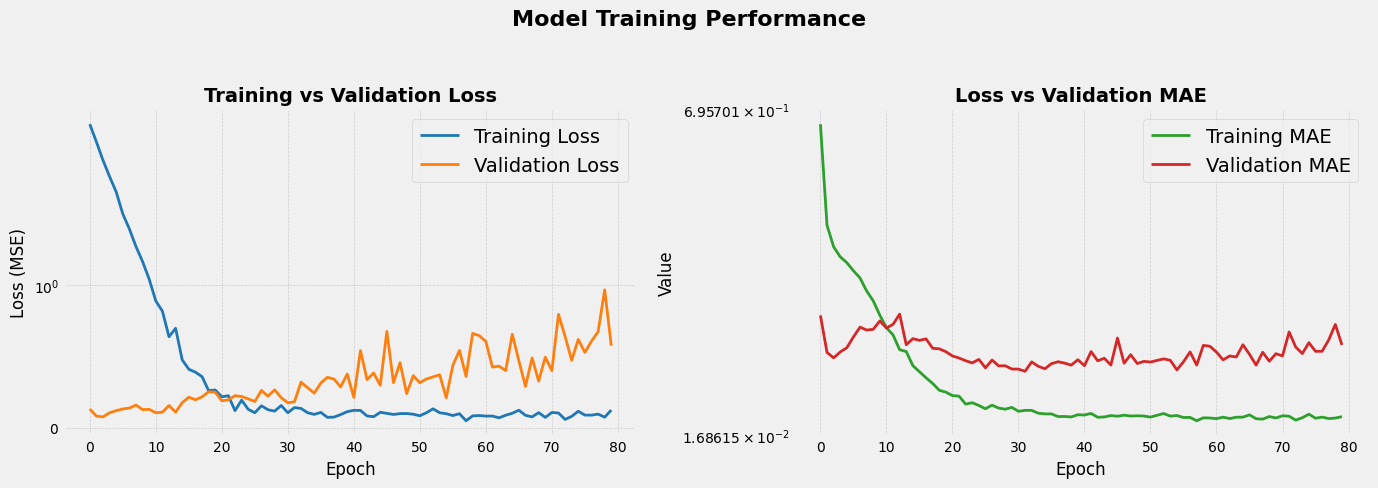

In [18]:
# Set global style for cleaner look
plt.style.use('fivethirtyeight')  # Optional: choose other styles like 'ggplot', 'fivethirtyeight'

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# --- Subplot 1: Loss ---
axs[0].plot(history.history['loss'], label='Training Loss', color='tab:blue', linewidth=2)
axs[0].plot(history.history['val_loss'], label='Validation Loss', color='tab:orange', linewidth=2)
axs[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Epoch', fontsize=12)
axs[0].set_ylabel('Loss (MSE)', fontsize=12)
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5) 
axs[0].legend()
axs[0].set_yscale('symlog')  # optional, as in your original
axs[0].tick_params(labelsize=10)

# --- Subplot 2: Loss vs MAE ---
axs[1].plot(history.history['mae'], label='Training MAE', color='tab:green', linewidth=2)
axs[1].plot(history.history['val_mae'], label='Validation MAE', color='tab:red', linewidth=2)
axs[1].set_title('Loss vs Validation MAE', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Epoch', fontsize=12)
axs[1].set_ylabel('Value', fontsize=12)
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].legend()
axs[1].set_yscale('symlog')  # optional
axs[1].tick_params(labelsize=10)

plt.suptitle('Model Training Performance', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [19]:
# Load new data — it should look like your original df
new_file_df = data[data['file'] == 'datasets/256_Al/Dv1.0']  # or whatever new file

# Make sure it's sorted by timestep
new_file_df = new_file_df.sort_values('timestep')


In [20]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)


In [21]:
y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()

293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


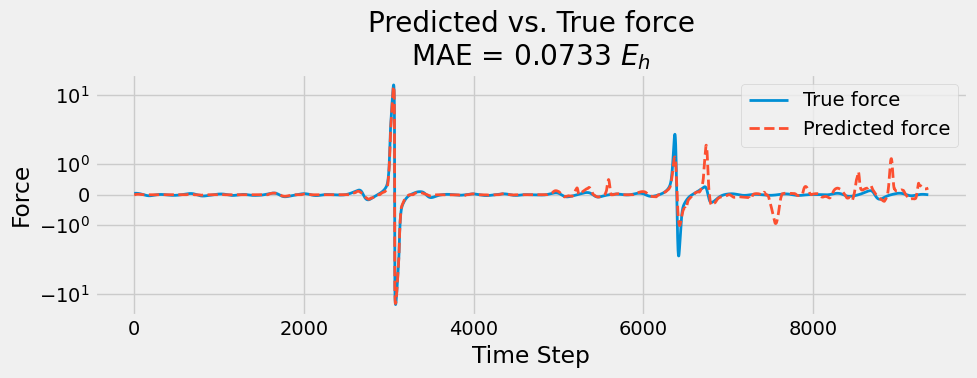

In [21]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True {y_col}\nMAE = {mae:.4f} $E_h$')
plt.yscale("symlog")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

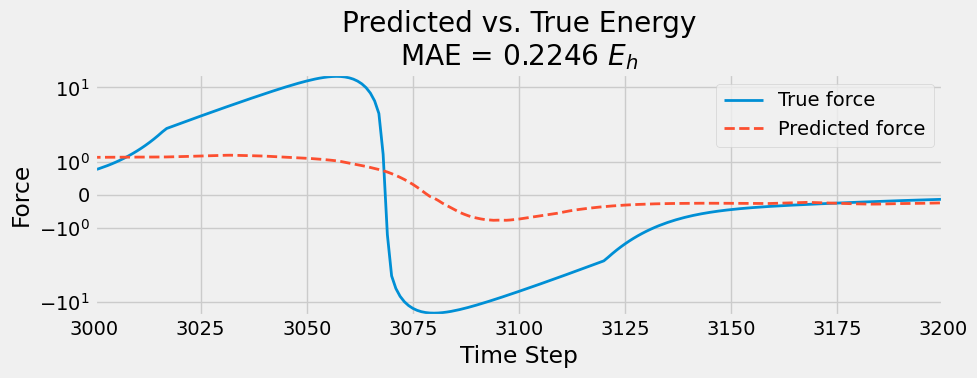

In [22]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True Energy\nMAE = {mae:.4f} $E_h$')
plt.legend()
plt.xlim(3000,3200)
plt.yscale("symlog")
plt.grid(True)
plt.tight_layout()
plt.show()

## Attempting a Recurrent Neural Network

### Creating Sliding Window Sequences for RNN Input

This section prepares the input data (`X`) and target labels (`y`) for training a recurrent neural network (RNN).

- The data is grouped by `file_id`, so each group represents a separate trajectory or simulation.
- Within each group, rows are sorted by `timestep` to preserve temporal order.
- A **sliding window** is applied to extract sequences of input features.
- For each sequence of 100 time steps, the corresponding target value is the value of `y_col` at the next time step (`t + 100`).
- The result is:
  - `X`: a 3D array of shape `(num_sequences, 100, num_features)`
  - `y`: a 1D array of target values, one for each sequence


In [66]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

data[X_cols] = x_scaler.fit_transform(data[X_cols])
data[y_col] = y_scaler.fit_transform(data[[y_col]])

In [67]:
sequence_col = 'file_id'  # column to group sequences by
timesteps = 5  # number of past steps used to predict the future

sequences = []  # list to store input sequences
targets = []  # list to store target values

for _, group in data.groupby(sequence_col):  # group data by sequence ID
    group = group.sort_values('timestep')  # ensure time order within each group
    x = group[X_cols].values  # extract input features
    y = group[y_col].values  # extract target values

    for i in range(len(group) - timesteps):  # slide window over each group
        sequences.append(x[i:i+timesteps])  # collect input sequence
        targets.append(y[i+timesteps])  # collect target after the sequence

X = np.array(sequences)  # convert input sequences to NumPy array
y = np.array(targets)  # convert targets to NumPy array


In [68]:
sequences = []
targets = []

for _, group in data.groupby(sequence_col):
    group = group.sort_values('timestep')
    x = group[X_cols].values
    y = group[y_col].values

    for i in range(len(group) - timesteps):
        sequences.append(x[i:i+timesteps])
        targets.append(y[i+timesteps])

X = np.array(sequences)        # shape: (samples, timesteps, features)
y = np.array(targets).reshape(-1, 1)  # reshape to 2D for scaler

print(X.shape)
print(X.reshape(-1, X.shape[-1]))

(9349, 5, 27)
[[-0.24345184  0.72120524 -0.04318896 ... -0.33970472 -0.3044786
  -1.73186614]
 [-0.24201891  0.70359636 -0.04317814 ... -0.3493031  -0.31301757
  -1.7314968 ]
 [-0.24057023  0.68605753 -0.04316639 ... -0.35882592 -0.32141012
  -1.73112745]
 ...
 [-0.21196863 -0.03326835 -0.04851232 ...  0.44049806 -0.18659913
   1.7307581 ]
 [-0.21089538 -0.03259563 -0.04848846 ...  0.44297162 -0.18131492
   1.73112745]
 [-0.20983517 -0.03176333 -0.04846118 ...  0.44537307 -0.17594455
   1.7314968 ]]


In [69]:
# Step 1: Split into train/validation (70/30 split)
num_samples = len(X)
split_index = int(0.5 * num_samples)

X_train, y_train = X[:split_index], y[:split_index]
X_val, y_val = X[split_index:], y[split_index:]

# Step 2: Create tf.data.Dataset objects
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# Step 3: Prepare datasets
batch_size = 128

train_ds = (
    train_ds
    .shuffle(buffer_size=len(X_train))   # Shuffle only train set
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN, Normalization, BatchNormalization, Activation

# Assume X shape is (samples, timesteps, features)
X_flat = X.reshape(-1, X.shape[-1])  # collapse time dimension

norm_layer = Normalization()
norm_layer.adapt(X_flat)  # learns mean/std for each feature across time and samples

# model = Sequential([
#     norm_layer,
#     LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
#     Dropout(0.2),
#     LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
#     Dense(32), #, activation='relu'), # removed relu since target can be negative
#     Dropout(0.2),
#     Dense(1)
# ])

# model = Sequential([
#     norm_layer,
#     LSTM(64, input_shape=(X.shape[1], X.shape[2])),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(1)
# ])
{'lstm_units': 16, 'dropout_rate': 0.1, 'dense_units': 32, 'learning_rate': 0.001, 'l1_kernel': 0.005, 'l1_recurrent': 0.0, 'activation': 'relu'}
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
keras.backend.clear_session()


model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# {'lstm_units': 128, 'dropout_rate': 0.2, 'dense_units': 64, 'learning_rate': 0.0001, 'num_lstm_layers': 1, 'activation': 'relu'}
# 🎯 Best Validation MAE: 0.0544

NameError: name 'regularizers' is not defined

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=100,
                    validation_data=val_ds,
                    callbacks=[early_stop])

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0725 - mae: 0.0566 - val_loss: 0.4812 - val_mae: 0.1816
Epoch 2/100
109/203 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1238 - mae: 0.0680

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation, Bidirectional, Normalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import numpy as np
import random

# === Example Input ===
# X: shape = (samples, timesteps, features)
# train_ds, val_ds: tf.data.Dataset objects
# This example assumes X is already defined.
# If not, define X, train_ds, and val_ds accordingly.

# TO DO
# Redo kernel and recurrent later with batchsize and timestep later

# === Search Space ===
search_space = {
    'lstm_units': [4, 8, 16, 32, 64],
    'dropout_rate': [0.1, 0.2, 0.3],
    'dense_units': [4, 8, 16, 32],
    'learning_rate': [1e-4, 3e-4, 1e-3],
    'l1_kernel': [0.0, 0.001, 0.005],
    'l1_recurrent': [0.0, 0.001, 0.005],
    'activation': ['relu', 'tanh']
}

# === Random Config Sampler ===
def random_sample_configs(space, num_trials=10):
    configs = []
    for _ in range(num_trials):
        config = {
            'lstm_units': random.choice(space['lstm_units']),
            'dropout_rate': random.choice(space['dropout_rate']),
            'dense_units': random.choice(space['dense_units']),
            'learning_rate': random.choice(space['learning_rate']),
            'l1_kernel': random.choice(space['l1_kernel']),
            'l1_recurrent': random.choice(space['l1_recurrent']),
            'activation': random.choice(space['activation'])
        }
        configs.append(config)
    return configs

# === Model Builder ===
def build_bidirectional_lstm_model(input_shape, config, norm_layer):
    kernel_reg = regularizers.L1(config['l1_kernel']) if config['l1_kernel'] > 0 else None
    recurrent_reg = regularizers.L1(config['l1_recurrent']) if config['l1_recurrent'] > 0 else None

    model = Sequential()
    model.add(norm_layer)

    model.add(Bidirectional(
        LSTM(config['lstm_units'],
             return_sequences=False,
             kernel_regularizer=kernel_reg,
             recurrent_regularizer=recurrent_reg),
        input_shape=input_shape
    ))

    model.add(Dropout(config['dropout_rate']))
    model.add(Dense(config['dense_units']))
    model.add(Activation(config['activation']))
    model.add(Dropout(config['dropout_rate']))
    model.add(Dense(1))  # Output: regression scalar

    return model

# === Hyperparameter Search Runner ===
def run_bidirectional_lstm_search(X, train_ds, val_ds, num_trials=10):
    input_shape = (X.shape[1], X.shape[2])

    # Normalize
    norm_layer = Normalization()
    X_flat = X.reshape(-1, X.shape[-1])
    norm_layer.adapt(X_flat)

    best_mae = float('inf')
    best_config = None
    results = []

    configs = random_sample_configs(search_space, num_trials)

    for i, config in enumerate(configs):
        print(f"\n🔁 Trial {i+1}/{num_trials} | Config: {config}")
        K.clear_session()

        model = build_bidirectional_lstm_model(input_shape, config, norm_layer)
        optimizer = tf.keras.optimizers.Adam(learning_rate=config['learning_rate'])
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=100,
            callbacks=[early_stop],
            verbose=0
        )

        val_mae = min(history.history['val_mae'])
        print(f"✅ Trial {i+1} finished — Best Validation MAE: {val_mae:.4f}")
        results.append((config, val_mae))

        if val_mae < best_mae:
            best_mae = val_mae
            best_config = config

    print("\n🏆 Best Configuration Found:")
    print(best_config)
    print(f"🎯 Best Validation MAE: {best_mae:.4f}")

    return best_config, results


In [16]:
best_config, results = run_bidirectional_lstm_search(X, train_ds, val_ds, num_trials=60)


🔁 Trial 1/60 | Config: {'lstm_units': 8, 'dropout_rate': 0.2, 'dense_units': 4, 'learning_rate': 0.0003, 'l1_kernel': 0.001, 'l1_recurrent': 0.0, 'activation': 'relu'}
✅ Trial 1 finished — Best Validation MAE: 0.0995

🔁 Trial 2/60 | Config: {'lstm_units': 4, 'dropout_rate': 0.1, 'dense_units': 4, 'learning_rate': 0.0003, 'l1_kernel': 0.0, 'l1_recurrent': 0.001, 'activation': 'tanh'}
✅ Trial 2 finished — Best Validation MAE: 0.1519

🔁 Trial 3/60 | Config: {'lstm_units': 4, 'dropout_rate': 0.1, 'dense_units': 8, 'learning_rate': 0.0001, 'l1_kernel': 0.0, 'l1_recurrent': 0.0, 'activation': 'relu'}
✅ Trial 3 finished — Best Validation MAE: 0.1152

🔁 Trial 4/60 | Config: {'lstm_units': 16, 'dropout_rate': 0.3, 'dense_units': 16, 'learning_rate': 0.001, 'l1_kernel': 0.0, 'l1_recurrent': 0.0, 'activation': 'tanh'}
✅ Trial 4 finished — Best Validation MAE: 0.1828

🔁 Trial 5/60 | Config: {'lstm_units': 8, 'dropout_rate': 0.1, 'dense_units': 8, 'learning_rate': 0.0003, 'l1_kernel': 0.001, 'l1_r

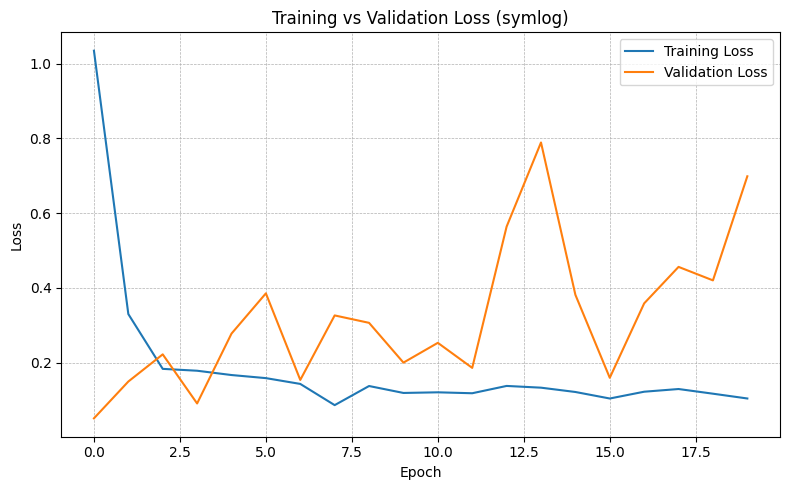

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (symlog)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

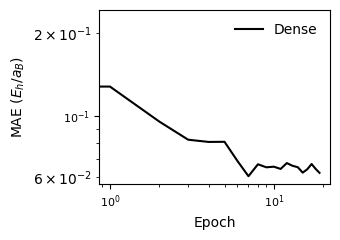

In [19]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(history.history['mae'], label='Dense', color='black', linewidth=1.5)

# Log-log axes
plt.xscale('log')
plt.yscale('log')

# Axis labels with scientific formatting
plt.xlabel('Epoch', fontsize=10)
plt.ylabel(r'MAE ($E_h / a_B$)', fontsize=10)

# Minimalist legend
plt.legend(frameon=False, loc='upper right')

# Ticks and layout
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(False)
plt.tight_layout()
plt.show()



In [20]:
# Load new data — it should look like your original df
new_file_df = data[data['file'] == 'datasets/256_Al/Dv1.0']  # or whatever new file

# Make sure it's sorted by timestep
new_file_df = new_file_df.sort_values('timestep')


In [21]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)


In [22]:
y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()

290/290 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


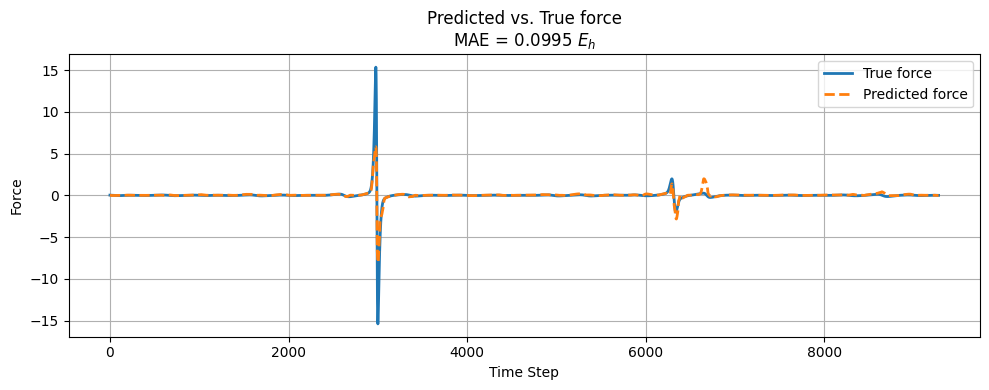

In [23]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True {y_col}\nMAE = {mae:.4f} $E_h$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


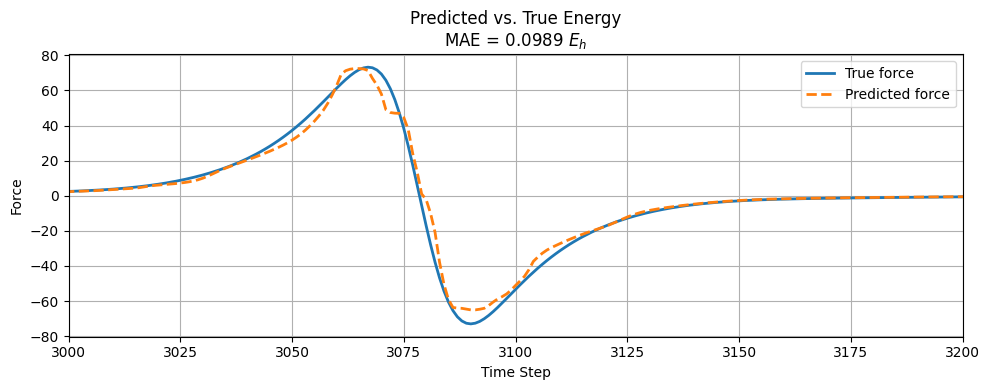

In [31]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True Energy\nMAE = {mae:.4f} $E_h$')
plt.legend()
plt.xlim(3000,3200)
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
timesteps = data['timestep'].iloc[-len(y_test):]  # For plotting

test_start_idx = len(data) - len(y_test)  # crude estimate if you're slicing from the end
timesteps = data['timestep'].iloc[test_start_idx:test_start_idx + len(y_test)].values

training_sizes = [250, 2500, 4690, 7000]
best_results = {
    'over_time': {
        'training_size': [],
        'step': [],
        'y_pred': [],
        'mae': [],
    }
}

for size in training_sizes:
    X_sub, y_sub = X_train[:size], y_train[:size]

    model = Sequential([
        LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    model.fit(X_sub, y_sub, epochs=20, verbose=0)

    y_pred = model.predict(X_test).flatten()
    mae = np.mean(np.abs(y_pred - y_test))  # or sklearn's mean_absolute_error

    best_results['over_time']['training_size'].append(size)
    best_results['over_time']['step'].append(size)  # You can replace with a timestep if relevant
    best_results['over_time']['y_pred'].append(y_pred)
    best_results['over_time']['mae'].append(mae)


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Determine the best algorithm
As the force acting on a particle varies by several orders of magnitude and changes sign, I will use the Spearman's correlation coefficient to determine the optimal algorithm. Usually, I like to use MAE. Given the large range of forces, small variations in the very large forces have a greater impact on the MAE than relatively similar changes on the small forces. I could also use the MRE or fit to the log of the error, but the sign change makes those routes impractical. So, I choose the Spearman's correlation coefficient 

In [40]:
print('{} models were tested'.format(len(test_results)))

9 models were tested


In [41]:
num_tests = len(test_results['ols']['over_time']['traj'])

In [42]:
experiment_number = int(num_tests * 0.5)

small_forces = np.logical_and(data['force'] > 0, data['force'] < 0.4)
train_size = test_results['lasso']['over_time']['training_size'][experiment_number]
print('Training set size: ', train_size)
results = dict([
    (name, {'force_mae': np.abs(data[y_col] - my_data['over_time']['traj'][experiment_number]).mean(),
            'small_force_mae': np.abs(data[y_col][small_forces] - \
                                my_data['over_time']['traj'][experiment_number][small_forces]).mean(),
            'force_spearman': stats.spearmanr(data[y_col],
                                              my_data['over_time']['traj'][experiment_number])[0]})
    for name, my_data in test_results.items()
])
del results['dummy']
over_time_results = pd.DataFrame(results).T
over_time_results.sort_values('force_spearman', ascending=False, inplace=True)
over_time_results

Training set size:  4690


,force_mae,small_force_mae,force_spearman
lasso_poly,0.296848,0.057218,0.880284
lasso+bayes_poly,0.313361,0.074323,0.776355
pca+bayes_poly,1.290449,0.462554,0.525099
bayes,0.325719,0.162300,0.503168
ols,0.355829,0.168385,0.480453
bayes_poly,22543.755423,3830.075113,0.077112
lasso,0.800455,0.194521,-0.623541
lasso+bayes,1.034206,0.295904,-0.707344


In [43]:
experiment_number = int(num_tests * 0.5)

small_forces = np.logical_and(data['force'] > 0, data['force'] < 0.4)
train_size = test_results['lasso']['over_time']['training_size'][experiment_number]
print('Training set size: ', train_size)
results = dict([
    (name, {'force_mae': np.abs(data[y_col] - my_data['over_time']['traj'][experiment_number]).mean(),
            'small_force_mae': np.abs(data[y_col][small_forces] - \
                                my_data['over_time']['traj'][experiment_number][small_forces]).mean(),
            'force_spearman': stats.spearmanr(data[y_col],
                                              my_data['over_time']['traj'][experiment_number])[0]})
    for name, my_data in test_results.items()
])
del results['dummy']
over_time_results = pd.DataFrame(results).T
over_time_results.sort_values('force_spearman', ascending=False, inplace=True)
over_time_results

Training set size:  4690


,force_mae,small_force_mae,force_spearman
lasso_poly,0.296848,0.057218,0.880284
lasso+bayes_poly,0.313361,0.074323,0.776355
pca+bayes_poly,1.290449,0.462554,0.525099
bayes,0.325719,0.162300,0.503168
ols,0.355829,0.168385,0.480453
bayes_poly,22543.755423,3830.075113,0.077112
lasso,0.800455,0.194521,-0.623541
lasso+bayes,1.034206,0.295904,-0.707344


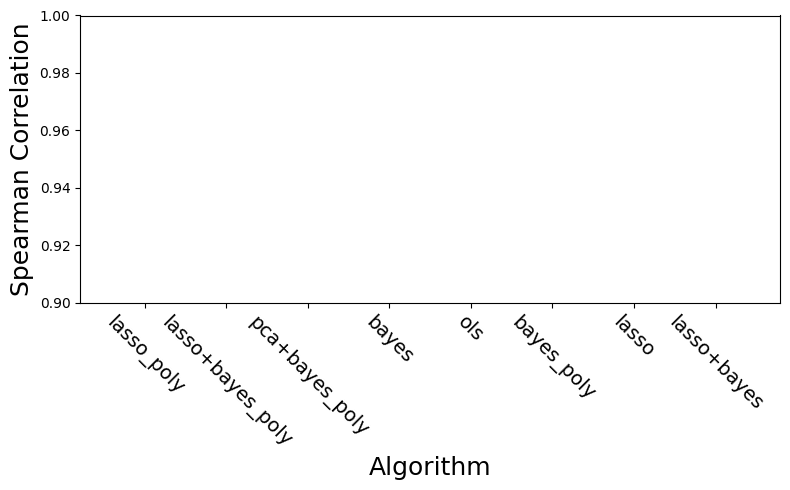

In [51]:
fig, ax = plt.subplots()

ax.bar(range(len(over_time_results)), over_time_results['force_spearman'])

ax.set_xticks(range(len(over_time_results)))
ax.set_xticklabels(list(over_time_results.index), fontsize=14, rotation=-45);

ax.set_ylim(0.9, 1)
ax.set_ylabel('Spearman Correlation', fontsize=18)
ax.set_xlabel('Algorithm', fontsize=18)

fig.set_size_inches(8, 5)
fig.tight_layout()

Show the tradeoff between the spearman $\rho$ and MAE

Best MAE: lasso_poly
Best SCC: lasso_poly


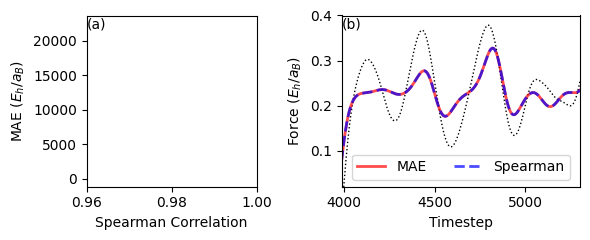

In [52]:
fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios':[1,1.4]})

# Plot all the performances
axs[0].scatter(over_time_results['force_spearman'],
          over_time_results['force_mae'])

axs[0].set_xlabel('Spearman Correlation')
axs[0].set_ylabel('MAE ($E_h / a_B$)')
axs[0].set_xlim(0.96, 1.0)
axs[0].text(0.0, 0.99, '(a)', va='top', transform=axs[0].transAxes)

# Plot the best MAE vs Best SCC
best_mae = over_time_results['force_mae'].idxmin()
print(f'Best MAE: {best_mae}')
best_scc = over_time_results['force_spearman'].idxmax()
print(f'Best SCC: {best_scc}')

tddft, = axs[1].plot(data['timestep'], data['force'], 'k:', lw=1, label='none')
tddft.set_label(None)
axs[1].set_ylim([0.02,0.4]) # Make sure the scales stay appropriate
axs[1].set_xlim(3990, 5300)

traj = test_results[best_mae]['over_time']['traj'][experiment_number]
axs[1].plot(data['timestep'], traj, 'r-', alpha=0.7, lw=2, label='MAE')

traj = test_results[best_scc]['over_time']['traj'][experiment_number]
axs[1].plot(data['timestep'], traj, 'b--', alpha=0.7, lw=2, label='Spearman')

axs[1].set_xlabel('Timestep')
axs[1].set_ylabel('Force ($E_h/a_B$)')
axs[1].legend(ncol=2, loc='lower center')

axs[1].text(0.0, 0.99, '(b)', va='top', transform=axs[1].transAxes)

fig.set_size_inches(6, 2.5)
fig.tight_layout()
fig.savefig(os.path.join('figures', 'mae-vs-spearman.png'), dpi=320)
fig.savefig(os.path.join('figures', 'mae-vs-spearman.pdf'))

*Finding*: The model selected using spearman fits low-force data more accurately

Save the results

In [53]:
with open('model-comparision-results.pkl', 'wb') as fp:
    pkl.dump(test_results, fp)

Select the best model

In [54]:
best_model = over_time_results.index[0]
print('Best model:', best_model)

Best model: lasso_poly


## Plot just the best one
Show the model performance

In [63]:
best_results = test_results['lasso+bayes_poly'] # This fits the data the best at large training set sizes

In [64]:
pkl.dump(best_results['model'], open('best_model.pkl', 'wb'))

Plot how well the algorithm forecasts stopping force

NameError: name 'y_pred' is not defined

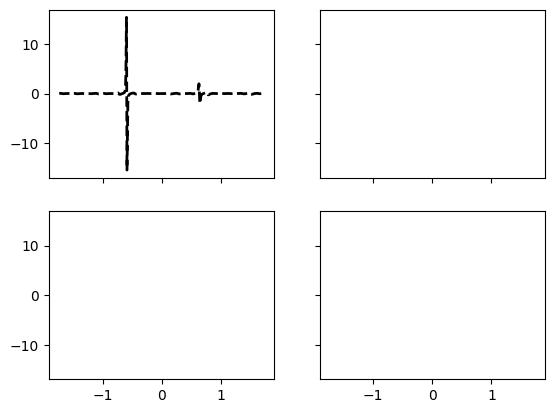

In [65]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)


for f,ax in zip([0,int(0.25*num_tests),int(0.5*num_tests),int(0.75*num_tests)],axs.flatten()):
    
    ax.plot(data['timestep'], data['force'], 'k--', lw=2)
    ax.set_ylim(ax.get_ylim()) # Make sure the scales stay appropriate
    
    traj = y_pred
    ax.plot(data['timestep'], traj, 'r-', alpha=0.7, lw=2)
    traj_error = np.abs(traj - data['force']).mean()
    
    ax.text(4200, 30, 'MAE: %.3f $E_H/a_B$'%traj_error, fontsize=18,
           bbox=dict(edgecolor='k', facecolor='w'))
    
    ax.text(4000, -80, 'Training size: %d'%best_results['over_time']['training_size'][f],
            fontsize=18,
           bbox=dict(edgecolor='k', facecolor='w'))
    
    ax.plot([best_results['over_time']['step'][f],]*2, ax.get_ylim(), 'b--')
    
    ax.set_yscale('symlog')

axs[1,0].set_xlabel('Timestep', fontsize=18)
axs[1,1].set_xlabel('Timestep', fontsize=18)
axs[0,0].set_ylabel('Force ($E_H/a_B$)', fontsize=18)
axs[1,0].set_ylabel('Force ($E_H/a_B$)', fontsize=18)

fig.set_size_inches(13,6)
fig.tight_layout()

fig.savefig(os.path.join('figures', 'random-trajectory-fit.png'), dpi=320)

In [ ]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)


for f,ax in zip([0,int(0.25*num_tests),int(0.5*num_tests),int(0.75*num_tests)],axs.flatten()):
    
    ax.plot(data['timestep'], data['force'], 'k--', lw=2)
    ax.set_ylim([0,0.4]) # Make sure the scales stay appropriate
    ax.set_xlim(4000, 5000)
    
    traj = best_results['over_time']['traj'][f]
    ax.plot(data['timestep'], traj, 'r-', alpha=0.7, lw=2)
    traj_error = np.abs(traj - data['force']).mean()
    
    ax.text(0.6, 0.9, 'MAE: %.3f $E_H/a_B$'%traj_error, fontsize=18,
           bbox=dict(edgecolor='k', facecolor='w'), transform=ax.transAxes)
    
    ax.text(0.6, 0, 'Training size: %d'%best_results['over_time']['training_size'][f],
            fontsize=18, bbox=dict(edgecolor='k', facecolor='w'), transform=ax.transAxes)
    
    ax.plot([best_results['over_time']['step'][f],]*2, ax.get_ylim(), 'b--')

axs[1,0].set_xlabel('Timestep', fontsize=18)
axs[1,1].set_xlabel('Timestep', fontsize=18)
axs[0,0].set_ylabel('Force ($E_H/a_B$)', fontsize=18)
axs[1,0].set_ylabel('Force ($E_H/a_B$)', fontsize=18)

fig.set_size_inches(13,6)
fig.tight_layout()

The above figure shows the fitness of the model as a function of training set size. In each frame, the model is trained on the data to the left of the blue, vertical line. The predictions of the model are shown in red and the TD-DFT result in black. After we've trained the model on half of the dataset (bottom left), the model fits the entire trajectory very well. At this point, we could stop the TD-DFT simulation and, instead, use our ML surrogate to compute the stopping power. By using the surrogate instead, we would get the same result as TD-DFT with only half of the computational expense.

### Make a learning curve
Show the MAE as training set size

In [ ]:
first_pass = data['timestep'][data['force'].idxmax()]
second_pass = data['timestep'][(data['force'].iloc[5000:]).idxmax()]
print('First pass is near timestep', first_pass)
print('Second pass is near timestep', second_pass)

In [ ]:
fig, ax = plt.subplots()

maes = [np.abs(data['force'] - t).mean() for t in test_results[best_scc]['over_time']['traj']]
sccs = [1 - stats.spearmanr(data['force'], t)[0] for t in test_results[best_scc]['over_time']['traj']]

ax.semilogy(test_results[best_scc]['over_time']['training_size'], maes, 'o-', markersize=4)
ax2 = ax.twinx()

ax2.semilogy(test_results[best_scc]['over_time']['training_size'], sccs, 'o-', color='crimson', markersize=4)
ax2.set_ylim(0.6, 4e-3)
ax2.set_ylabel('1 - $ \\rho $')

ax.annotate('1$^{st}$ Near Pass', xy=(first_pass - data['initial'].sum(), 1),
           xytext=(3500, 8), arrowprops={'facecolor': 'k', 'width': 1.5, 'headwidth': 4})
ax.annotate('2$^{nd}$ Near Pass', xy=(second_pass - data['initial'].sum(), 0.04),
           xytext=(3700, 0.5), arrowprops={'facecolor': 'k', 'width': 1.5, 'headwidth': 4})

ax.set_xlabel('Training Set Size')
ax.set_ylabel('MAE ($E_H / a_B$)')

fig.set_size_inches(3.5, 2.1)
fig.tight_layout()
fig.savefig(os.path.join('figures', 'random-learning-curve.png'), dpi=320)

## Make it an animation
Show the fitness improving as more training data is added

In [ ]:
model = best_results['model']

In [ ]:
frames = np.linspace(10, len(data) / 2, 200, dtype=int)

In [ ]:
fig, ax = plt.subplots()

ax.plot(data['timestep'], data['force'], 'k--', lw=2)

model.fit(data[X_cols].iloc[:10], data[y_col].iloc[:10])
lne, = ax.plot(data['timestep'], model.predict(data[X_cols]), 'r-', alpha=0.7, lw=2)
ax.set_ylim(ax.get_ylim())
bar, = ax.plot([data['timestep'].iloc[:1].max(),]*2, ax.get_ylim(), 'b--')

def update(frame):
    size = frames[frame]
    model.fit(data[X_cols].iloc[:size], data[y_col].iloc[:size])
    lne.set_data(data['timestep'], model.predict(data[X_cols]))
    
    bar.set_data([data['timestep'].iloc[:size].max(),]*2, ax.get_ylim())
    return lne, bar
    
anim = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)

ax.set_yscale('symlog')
ax.set_xlabel('Timestep', fontsize=18)
ax.set_ylabel('Force ($E_H/a_B$)', fontsize=18)
fig.tight_layout()
fig.set_size_inches(8, 4)

This video shows the changes in the fitness of the model as we add new training data. In each frame, the model is trained using all of the data to the left of the blue bar. The black line is the TD-DFT result and the red line in the ML prediction. Notice how the model first starts to accurately predict the stopping power in low-force region and then accurately models the high force regions. After we gather about half of the training data, our model predictions no longer fluctuate with adding more data. 

In [ ]:
anim.save(os.path.join('figures', 'training-animation.mp4'), dpi=330, writer='ffmpeg')